In [1]:
import numpy as np
import matplotlib as mpl
#mpl.use('pdf')
import matplotlib.pyplot as plt
import numpy as np

# plt.rc('font', family='serif', serif='Times')
# Arial
plt.rc('font', family='Arial')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)
plt.rc('axes', labelsize=11)
#axes.linewidth : 0.5
plt.rc('axes', linewidth=0.5)
#ytick.major.width : 0.5
plt.rc('ytick.major', width=0.5)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('ytick.minor', visible=True)

# set grid under the plot
# https://stackoverflow.com/questions/23357798/how-to-draw-grid-lines-behind-matplotlib-bar-graph
# https://stackoverflow.com/questions/1726391/matplotlib-draw-grid-lines-behind-other-graph-elements/39039520#39039520
plt.rc('axes', axisbelow=True)


#plt.style.use(r"..\..\styles\infocom.mplstyle") # Insert your save location here

# width as measured in inkscape
fig_width = 3.487
fig_height = fig_width / 1.618
# fig_height = 1.8
#fig_height = fig_width / 1.3 / 2

In [2]:
import numpy as np
num_instances = 5
# file_list = list(range(num_cases))
# filename_prefix = "results/results_japan_averaged_rate"
folder_prefix = "results/TS8Module10-0716-8Ins/"
acceptance_ratio = np.zeros((4, num_instances), dtype=float)
stored_keys = np.zeros((4, num_instances), dtype=float)
num_physical_hops = np.zeros((4, num_instances), dtype=float)
num_virtual_hops = np.zeros((4, num_instances), float)
num_qkd_module = np.zeros((4, num_instances), dtype=float)

case_prefix_list = ["results_qkp_No_OB_TR_german_averaged_rate", "results_qkp_OB_german_averaged_rate", 
         "results_qkp_TR_german_averaged_rate", "results_qkp_OB_TR_german_averaged_rate"]

In [3]:
average_key_rate_index = 4
for j in range(num_instances):
    #for file in file_list:
#     file = file_list[j]
    for i in range(len(case_prefix_list)):
        case_prefix = case_prefix_list[i]
        filename = folder_prefix + case_prefix + str(average_key_rate_index) + "_1.txt"
        with open(filename, "r") as f:
            lines = f.readlines()
            tmp = 100 * float(lines[0+2*j].split(" ")[0])
            acceptance_ratio[i][j] = tmp
            stored_keys[i][j] = float(lines[1+2*j].split(" ")[0])
            num_qkd_module[i][j] = float(lines[1+2*j].split(" ")[1])
            num_physical_hops[i][j] = float(lines[1+2*j].split(" ")[2])
            num_virtual_hops[i][j] = float(lines[1+2*j].split(" ")[3])
            
print(acceptance_ratio)
print(num_qkd_module)

[[ 19.3287037   19.3287037   19.3287037   19.3287037   19.3287037 ]
 [ 55.32407407  60.53240741  68.51851852  76.96759259  85.64814815]
 [ 48.61111111  57.06018519  66.08796296  79.51388889  96.75925926]
 [ 64.23611111  73.95833333  85.53240741  97.22222222 100.        ]]
[[2.         2.         2.         2.         2.        ]
 [2.         2.         2.         2.         2.        ]
 [3.60026629 3.15003352 2.54469423 2.02055453 1.34663561]
 [2.78511418 2.68186258 2.68920849 2.59381631 1.44251543]]


In [4]:
dataMatrix = acceptance_ratio
print(dataMatrix)

[[ 19.3287037   19.3287037   19.3287037   19.3287037   19.3287037 ]
 [ 55.32407407  60.53240741  68.51851852  76.96759259  85.64814815]
 [ 48.61111111  57.06018519  66.08796296  79.51388889  96.75925926]
 [ 64.23611111  73.95833333  85.53240741  97.22222222 100.        ]]


[0 1 2 3 4]
['0', '3', '6', '9', '12']


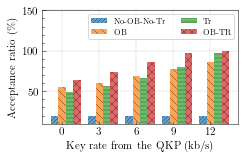

In [5]:
N = 5
ind = np.arange(N) 
width = 1 / 5

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['0', '3', '6', '9', '12']
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Acceptance ratio (\%)')
ax1.set_xlabel('Key rate from the QKP (kb/s)')
ax1.set_ylim(10, 150)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.17, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/qkp-acceptance-ratio.pdf')
fig.savefig('plot/qkp-acceptance-ratio.png')

In [6]:
dataMatrix = num_qkd_module
print(dataMatrix)

[[2.         2.         2.         2.         2.        ]
 [2.         2.         2.         2.         2.        ]
 [3.60026629 3.15003352 2.54469423 2.02055453 1.34663561]
 [2.78511418 2.68186258 2.68920849 2.59381631 1.44251543]]


In [15]:
dataMatrix = stored_keys
print(dataMatrix)

[[1332.09375    1333.890625   1335.6875     1337.484375   1339.28125   ]
 [ 756.43170878  631.77624071  488.62269451  335.59102958  247.78097203]
 [ 427.265625    -49.671875   -361.09375    -696.125      -927.390625  ]
 [ 256.5044893  -126.25303461 -441.04022058 -700.79195872 -815.16583625]]


[0 1 2 3 4]
['0', '3', '6', '9', '12']


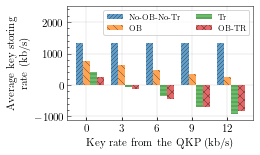

In [17]:
N = 5
ind = np.arange(N) 
width = 1 / 5

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['0', '3', '6', '9', '12']
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average key storing \n rate (kb/s)')
ax1.set_xlabel('Key rate from the QKP (kb/s)')
ax1.set_ylim(-1100, 2500)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.21, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/qkp-key-storing-rate.pdf')
fig.savefig('plot/qkp-key-storing-rate.png')

In [9]:
dataMatrix = num_qkd_module
print(dataMatrix)

[[2.         2.         2.         2.         2.        ]
 [2.         2.         2.         2.         2.        ]
 [3.60026629 3.15003352 2.54469423 2.02055453 1.34663561]
 [2.78511418 2.68186258 2.68920849 2.59381631 1.44251543]]


[0 1 2 3 4]
['0', '3', '6', '9', '12']


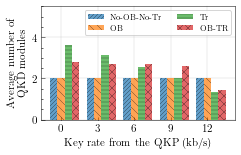

In [10]:
N = 5
ind = np.arange(N) 
width = 1 / 5

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['0', '3', '6', '9', '12']
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n QKD modules')
ax1.set_xlabel('Key rate from the QKP (kb/s)')
ax1.set_ylim(0, 5.5)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/qkp-num-qkd-modules.pdf')
fig.savefig('plot/qkp-num-qkd-modules.png')

In [18]:
dataMatrix = num_physical_hops
print(dataMatrix)

[[1.         1.         1.         1.         1.        ]
 [1.         1.         1.         1.         1.        ]
 [1.71004104 1.42886123 1.15519321 0.92692219 0.61115906]
 [1.30137205 1.25807169 1.26573397 1.22171586 0.70968364]]


[0 1 2 3 4]
['0', '3', '6', '9', '12']


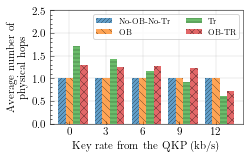

In [19]:
N = 5
ind = np.arange(N) 
width = 1 / 5

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['0', '3', '6', '9', '12']
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n physical hops')
ax1.set_xlabel('Key rate from the QKP (kb/s)')
ax1.set_ylim(0, 2.5)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/qkp-num-physical-hops.pdf')
fig.savefig('plot/qkp-num-physical-hops.png')

In [13]:
dataMatrix = num_virtual_hops
print(dataMatrix)

[[0.         0.16666667 0.2        0.25       0.33333333]
 [0.         0.14540527 0.1748938  0.21744367 0.29586675]
 [0.38662419 1.07443248 1.32135184 1.39158586 1.50321263]
 [0.26694601 0.58439011 0.72398122 0.88261912 1.22608025]]


[0 1 2 3 4]
['0', '3', '6', '9', '12']


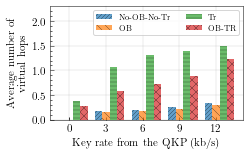

In [14]:
N = 5
ind = np.arange(N) 
width = 1 / 5

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['0', '3', '6', '9', '12']
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n virtual hops')
ax1.set_xlabel('Key rate from the QKP (kb/s)')
ax1.set_ylim(0, 2.3)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/qkp-num-virtual-hops.pdf')
fig.savefig('plot/qkp-num-virtual-hops.png')